<a href="https://colab.research.google.com/github/KaterinSalazar/biosignals/blob/main/Proyecto1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Instalación de librerias

In [ ]:
!pip install mne
!pip install scikit-posthocs
!pip install openneuro-py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 44.6 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
!pip install gdown

##Importación de linbreriías

In [ ]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import welch
import mne
import pandas as pd
from scipy.stats import shapiro
import seaborn as sns
from scipy.stats  import wilcoxon, kruskal, ttest_rel, f_oneway,skew,kurtosis
from statsmodels.stats.multitest import multipletests
from scikit_posthocs    import posthoc_dunn
import gdown
from openneuro import download
import os

In [ ]:
#Descarga de archivos, esperar 5 minutos
download(
    dataset="ds004362",
    target_dir="datos",
    include=[
        "sub-*/eeg/*run-3*_eeg.set",
        "sub-*/eeg/*run-4*_eeg.set",
        "sub-*/eeg/*run-7*_eeg.set",
        "sub-*/eeg/*run-8*_eeg.set",
        "sub-*/eeg/*run-11*_eeg.set",
        "sub-*/eeg/*run-12*_eeg.set",
    ]
)


👋 Hello! This is openneuro-py 2026.4.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004362 …
📥 Retrieving up to 659 files (5 concurrent downloads). 

✅ Finished downloading ds004362.
 
🧠 Please enjoy your brains.
 


In [ ]:
mne.set_log_level('ERROR') #Ocultar spam de funciones

# ─────────────────────────────────────────────
# Configuración global por defecto
# ─────────────────────────────────────────────
RUNS_REAL      = [3, 7, 11]
RUNS_IMAGINADO = [4, 8, 12]
RUNS_VALIDOS   = RUNS_REAL + RUNS_IMAGINADO

TMIN, TMAX     = -1.0, 4.0
N_ICA_COMP     = 20


# ─────────────────────────────────────────────
# Carga
# ─────────────────────────────────────────────
def cargar_raw(data_dir: str, sujeto: str, run: int) -> mne.io.Raw:
    """
    Carga un archivo .set de un sujeto/run

    Parameters
    ----------
    data_dir : str   Directorio raíz donde están los archivos.
    sujeto   : str   Identificador del sujeto, p. ej. 'sub-001'.
    run      : int   Número de run.

    Returns
    -------
    raw : mne.io.Raw con datos precargados en memoria.
    """
    archivo = f"{data_dir}/datos/{sujeto}/eeg/{sujeto}_task-motion_run-{run}_eeg.set"
    raw = mne.io.read_raw_eeglab(archivo, preload=True)
    return raw


# ─────────────────────────────────────────────
# 2. Preprocesamiento (filtrado + referencia)
# ─────────────────────────────────────────────
def preprocesar(raw: mne.io.Raw) -> mne.io.Raw:
    """
    Aplica filtro pasa-banda 1–35 Hz (FIR, ventana Hamming, fase cero)
    y referencia promedio a la señal cruda.

    Frecuencias de corte:
    - Inferior  7 Hz  → elimina deriva de línea base, DC offset, artefactos
                        de movimiento de baja frecuencia y bandas no deseadas
    - Superior 35 Hz  → elimina ruido de red eléctrica y artefactos
                        mioeléctricos de alta frecuencia.

    Parameters
    ----------
    raw : mne.io.Raw  Señal cruda cargada en memoria.

    Returns
    -------
    raw : mne.io.Raw  Señal filtrada y re-referenciada (in-place).
    """
    raw.filter(l_freq=7.0, h_freq=35.0, method='fir',
               fir_window='hamming', phase='zero')

    # Resta en cada instante la media de todos los canales → mejora SNR
    raw.set_eeg_reference(ref_channels='average', projection=False)
    return raw


# ─────────────────────────────────────────────
# 4. Segmentación en épocas
# ─────────────────────────────────────────────
# Mapeo de etiquetas reales del dataset
# Mapeo run -> número de task
RUN_TO_TASK = {3: 1, 4: 2, 7: 1, 8: 2, 11: 1, 12: 2}

def segmentar_epocas(raw_clean: mne.io.Raw, run: int,
                     min_epocas: int = 5) -> mne.Epochs:

    events, event_id = mne.events_from_annotations(raw_clean)
    task_num = RUN_TO_TASK[run]

    epoch_event_id = {
        'T0': event_id[f'TASK{task_num}T0'],
        'T1': event_id[f'TASK{task_num}T1'],
        'T2': event_id[f'TASK{task_num}T2']
    }

    epochs = mne.Epochs(
    raw_clean,
    events,
    event_id=epoch_event_id,
    tmin=TMIN,
    tmax=TMAX,
    baseline=None,
    reject=None,
    preload=True,
    verbose=False
)

    # Rechazo manual solo sobre C3 y C4 con umbral fijo de 100 µV
    c3_idx = epochs.ch_names.index('C3')
    c4_idx = epochs.ch_names.index('C4')
    data   = epochs.get_data()

    amp_c3 = np.abs(data[:, c3_idx, :]).max(axis=-1)
    amp_c4 = np.abs(data[:, c4_idx, :]).max(axis=-1)

    mask_buenas = (amp_c3 <= 100e-6) & (amp_c4 <= 100e-6)
    epochs = epochs[mask_buenas]

    print(f"  Umbral 100 µV → {len(epochs)} épocas ✓")
    return epochs


# ─────────────────────────────────────────────
# 5. Visualización (canal C3, ventana de 5 s)
# ─────────────────────────────────────────────

def graficar(raw: mne.io.Raw,
             raw_filtrada: mne.io.Raw,
             canal: str = 'C3',
             escala_uv: float = 100.0) -> None:
    """
    Grafica señal cruda y filtrada (7-35 Hz) alineadas al primer evento T1,
    mostrando 1s de basal + 4s de tarea.
    """
    inicio = None
    for ann in raw.annotations:
        if 'T1' in ann['description']:
            inicio = ann['onset'] - 1.0
            break

    if inicio is None or inicio < 0:
        inicio = 10.0

    duracion = 6.0
    sfreq    = raw.info['sfreq']
    i0       = int(inicio * sfreq)
    i1       = int((inicio + duracion) * sfreq)
    tiempos  = np.linspace(-1.0, duracion - 1.0, i1 - i0)

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    señales = [
        (raw,          'Bruta',            'steelblue'),
        (raw_filtrada, 'Filtrada 7-35 Hz', 'darkorange'),
    ]

    for ax, (r, titulo, color) in zip(axes, señales):
        data = r.get_data(picks=[canal])[0, i0:i1] * 1e6
        ax.plot(tiempos, data, color=color, linewidth=0.8)
        ax.axvline(0, color='red', linestyle='--',
                   linewidth=1.5, label='Onset T1')
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_title(titulo)
        ax.set_ylabel('Amplitud (µV)')
        ax.set_ylim(-escala_uv, escala_uv)
        ax.legend(loc='upper right', fontsize=8)

    axes[-1].set_xlabel('Tiempo relativo al onset (s)')
    plt.suptitle(f'Preprocesamiento — canal {canal}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────
# Configuración de bandas y canales
# ─────────────────────────────────────────────
BANDS = {
    'mu'   : (8,   13),
    'beta' : (13,  30),
    }

CHANNELS_OF_INTEREST = ['C3', 'C4']

# Mapeo evento -> condición legible
# T1 = mano izquierda/ambos puños, T2 = mano derecha/ambos pies
# runs reales: 3,7,11 | imaginados: 4,8,12
def get_condition(run: int, event_code: int) -> str:
    """
    Devuelve la condición semántica a partir del run y el código de evento.

    Run real      (3,7,11):  T1 → 'real_left'  | T2 → 'real_right'
    Run imaginado (4,8,12):  T1 → 'mi_left'    | T2 → 'mi_right'
    Evento 1 (T0/reposo):    → 'rest'
    """
    # event_code 1 = reposo (TASK1T0 / TASK2T0)
    if event_code == 1:
        return 'rest'

    es_real = run in RUNS_REAL

    if event_code == 2:   # T1
        return 'real_left'  if es_real else 'mi_left'
    if event_code == 3:   # T2
        return 'real_right' if es_real else 'mi_right'

    return 'unknown'

# ─────────────────────────────────────────────
# Paso 4 – PSD por época
# ─────────────────────────────────────────────
def compute_band_power(epoch_data: np.ndarray,
                       sfreq: float,
                       bands: dict) -> dict:
    """
    Estima la potencia media (µV²/Hz) en cada banda de frecuencia
    usando el método de Welch con ventanas Hann de 256 muestras y
    50% de solapamiento.

    Parameters
    ----------
    epoch_data : ndarray (n_channels, n_times)
        Datos de una época para los canales de interés.
    sfreq : float
        Frecuencia de muestreo en Hz.
    bands : dict
        {'nombre': (f_low, f_high)} con los rangos de cada banda.

    Returns
    -------
    band_power : dict
        {'nombre_banda': array(n_channels)} con potencia media en µV²/Hz.
    """

    """
    epoch_data viene en Voltios (MNE siempre trabaja en V internamente).
    Convertimos a µV antes de Welch para obtener potencias en µV²/Hz.
    """
    # V → µV  (1 V = 1e6 µV, potencia escala al cuadrado → 1e12)
    epoch_data_uv = epoch_data * 1e6

    freqs, psd = welch(epoch_data_uv, fs=sfreq,
                       nperseg=256, noverlap=128,
                       window='hann', axis=-1)

    band_power = {}
    for band, (flo, fhi) in bands.items():
        idx = np.logical_and(freqs >= flo, freqs <= fhi)
        # Área bajo la curva / ancho de banda → potencia media
        ancho_banda = fhi - flo
        band_power[band] = np.trapezoid(psd[:, idx], freqs[idx], axis=-1) / ancho_banda

    return band_power


# ─────────────────────────────────────────────
# 6. Orquestador principal
# ─────────────────────────────────────────────
def procesar_sujetos(data_dir: str,
                     n_sujetos: int = None,
                     sujeto_id: int = None,
                     visualizar: bool = False,
                     channels: list = CHANNELS_OF_INTEREST,
                         bands: dict = BANDS) -> pd.DataFrame:
    """
    Ejecuta el pipeline completo (carga → filtrado → épocas) para
    uno o todos los sujetos.

    Usa `sujeto_id` para procesar un único sujeto, o `n_sujetos` para
    procesar desde sub-001 hasta sub-{n_sujetos:03d}.
    Si ambos se omiten lanza un ValueError.

    Parameters
    ----------
    data_dir   : str   Ruta raíz con los archivos .set.
                       Ej.: '/content' en Google Colab.
    n_sujetos  : int   Procesar sujetos 1 … n_sujetos (opcional).
    sujeto_id  : int   Procesar solo este sujeto (opcional).
                       Tiene prioridad sobre n_sujetos.
    visualizar : bool  Si True, llama a graficar() en cada run (default False).

    channels   : list  Canales EEG a incluir en el DataFrame.
    bands      : dict  Bandas de frecuencia a estimar.

    Returns
    -------
    df : pd.DataFrame
        Columnas: subject, run, condition, epoch_idx,
                  C3_mu, C3_beta, C4_mu, ... (canal_banda)

    """
    if sujeto_id is not None:
        lista_sujetos = [sujeto_id]
    elif n_sujetos is not None:
        lista_sujetos = list(range(1, n_sujetos + 1))
    else:
        raise ValueError("Debes especificar 'sujeto_id' o 'n_sujetos'.")

    records = []  # ← aquí se acumulan las filas, no en 'datos'

    for j in lista_sujetos:
        sujeto = f"sub-{j:03d}"
        print(f"\n{'='*50}\nProcesando {sujeto} ...\n{'='*50}")
        infosignal = None
        for run in RUNS_VALIDOS:
            print(f"  Run {run:02d} ...", end=" ")

            try:
                raw          = cargar_raw(data_dir, sujeto, run)
                raw_filtrada = preprocesar(raw.copy())
                epochs       = segmentar_epocas(raw_filtrada, run)
                if infosignal is None:
                    infosignal = raw_filtrada.info

                if visualizar:
                  graficar(raw, raw_filtrada)           # ← sin raw_clean


                sfreq      = raw_filtrada.info['sfreq']
                ch_names   = [ch.upper() for ch in raw_filtrada.ch_names]
                ch_idx     = [ch_names.index(ch.upper()) for ch in channels]

                for ep_i, ep_data in enumerate(epochs.get_data()[:, ch_idx, :]):
                    event_code = epochs.events[ep_i, 2]
                    bp  = compute_band_power(ep_data, sfreq, bands)
                    row = {
                        'subject'  : sujeto,
                        'run'      : run,
                        'condition': get_condition(run, event_code),
                        'epoch_idx': ep_i,
                    }
                    for band, powers in bp.items():
                        for ch_i, ch in enumerate(channels):
                            row[f'{ch}_{band}'] = powers[ch_i]
                    records.append(row)

                tipo = "real" if run in RUNS_REAL else "imaginado"
                print(f"✓ Movimiento {tipo} — {len(epochs)} épocas\n")

            except Exception as e:
                print(f"✗  Skipped: {e}")
                continue

    df = pd.DataFrame(records)
    print(f"\nDataFrame construido: {df.shape[0]} filas × {df.shape[1]} columnas")
    return df, infosignal





In [ ]:
# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────

DATA_DIR = "/content"

print("=" * 50)
print("   PIPELINE EEG — Motor Imagery BCI")
print("=" * 50)
print("\n¿Qué deseas procesar?")
print("  1. Un solo sujeto   (con visualización)")
print("  2. Varios sujetos   (sin visualización)")
print("-" * 50)

while True:
    opcion = input("Selecciona una opción [1/2]: ").strip()
    if opcion in ['1', '2']:
        break
    print("  ⚠ Opción inválida — ingresa 1 o 2")

if opcion == '1':
    while True:
        try:
            n = int(input("Número del sujeto (ej. 1 para sub-001): ").strip())
            if 1 <= n <= 109:
                break
            print("  ⚠ El número debe estar entre 1 y 109")
        except ValueError:
            print("  ⚠ Ingresa un número entero válido")

    print(f"\n  ► Procesando sub-{n:03d} con visualización de gráficas...")
    print("=" * 50)
    df, infosignal = procesar_sujetos(DATA_DIR, sujeto_id=n, visualizar=True)

else:
    while True:
        try:
            n = int(input("¿Cuántos sujetos deseas procesar? (1-109): ").strip())
            if 1 <= n <= 109:
                break
            print("  ⚠ El número debe estar entre 1 y 109")
        except ValueError:
            print("  ⚠ Ingresa un número entero válido")

    print(f"\n  ► Procesando {n} sujeto(s) sin visualización de gráficas...")
    print("  ► Esto puede tardar varios minutos.")
    print("=" * 50)
    df, infosignal = procesar_sujetos(DATA_DIR, n_sujetos=n, visualizar=False)

print("\nPipeline finalizado.")
print(f"DataFrame: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

   PIPELINE EEG — Motor Imagery BCI

¿Qué deseas procesar?
  1. Un solo sujeto   (con visualización)
  2. Varios sujetos   (sin visualización)
--------------------------------------------------
Selecciona una opción [1/2]: 2
¿Cuántos sujetos deseas procesar? (1-109): 109

  ► Procesando 109 sujeto(s) sin visualización de gráficas...
  ► Esto puede tardar varios minutos.

Procesando sub-001 ...
  Run 03 ...   Umbral 100 µV → 29 épocas ✓
✓ Movimiento real — 29 épocas

  Run 07 ...   Umbral 100 µV → 29 épocas ✓
✓ Movimiento real — 29 épocas

  Run 11 ...   Umbral 100 µV → 29 épocas ✓
✓ Movimiento real — 29 épocas

  Run 04 ...   Umbral 100 µV → 29 épocas ✓
✓ Movimiento imaginado — 29 épocas

  Run 08 ...   Umbral 100 µV → 29 épocas ✓
✓ Movimiento imaginado — 29 épocas

  Run 12 ...   Umbral 100 µV → 29 épocas ✓
✓ Movimiento imaginado — 29 épocas


Procesando sub-002 ...
  Run 03 ...   Umbral 100 µV → 27 épocas ✓
✓ Movimiento real — 27 épocas

  Run 07 ...   Umbral 100 µV → 28 épocas ✓
✓ M

,subject,run,condition,epoch_idx,C3_mu,C4_mu,C3_beta,C4_beta
0,sub-001,3,real_right,0,2.721034,4.838542,2.365357,1.727581
1,sub-001,3,rest,1,4.840642,4.309072,3.399841,2.219672
2,sub-001,3,real_left,2,4.350694,4.372162,2.285690,2.548791
3,sub-001,3,rest,3,2.372463,3.670566,3.371879,2.319997
4,sub-001,3,real_left,4,2.193187,2.357328,2.281665,1.993063


In [ ]:
meta_cols    = ['subject', 'run', 'condition', 'epoch_idx']
feature_cols = [c for c in df.columns if c not in meta_cols]

In [ ]:
def remove_outlier_subjects(df: pd.DataFrame,
                             feature_cols: list,
                             n_std: float = 3.0) -> pd.DataFrame:
    """
    Excluye sujetos cuya potencia media supera n_std desviaciones
    estándar en cualquier canal o banda. El umbral se calcula UNA
    sola vez sobre todos los sujetos — no itera ni recalcula.
    """
    # media por sujeto para todas las features de una vez
    medias = df.groupby('subject')[feature_cols].mean()
    #  umbral global por columna: media + n_std * std
    umbrales = medias.mean() + n_std * medias.std()

    # mascara: True si el sujeto supera el umbral en CUALQUIER columna
    es_outlier = (medias > umbrales).any(axis=1)

    sujetos_malos = medias[es_outlier].index.tolist()

    if sujetos_malos:
        print(f"Sujetos excluidos: {sujetos_malos}")
    else:
        print("No se encontraron sujetos outliers")

    print(f"Sujetos restantes: {df[~df['subject'].isin(sujetos_malos)]['subject'].nunique()} / {df['subject'].nunique()}")

    return df[~df['subject'].isin(sujetos_malos)]

In [ ]:
df=remove_outlier_subjects(df,feature_cols)

Sujetos excluidos: ['sub-013', 'sub-048', 'sub-049', 'sub-054', 'sub-099']
Sujetos restantes: 103 / 108


#Análisis estadístico

###Visualización exploratoria

In [ ]:
def descriptive_statistics(df: pd.DataFrame,
                            channels: list,
                            bands_list: list = ['mu', 'beta'],
                            conditions: list = ['rest', 'real_left', 'real_right', 'mi_left', 'mi_right']
                            ) -> tuple:
    """
    Ejecuta la estadística descriptiva y visualización exploratoria completa
    sobre el DataFrame de potencia espectral EEG (sección 5.1 del análisis).

    Genera cuatro salidas:
        1. Tabla descriptiva general (describe estándar).
        2. Tabla descriptiva por condición (media, mediana, std, asimetría, curtosis).
        3. Barplot C3 vs C4 por condición y banda (reemplaza topomap).
        4. Violin plots de distribución por canal y banda.
        5. Box plots + stripplot de C3 vs C4 por condición.
        6. Heatmaps de potencia media canal × banda por condición.

    Parameters
    ----------
    df         : pd.DataFrame
                 DataFrame generado por procesar_sujetos(). Debe contener las
                 columnas: subject, run, condition, epoch_idx, y columnas de
                 potencia con formato {canal}_{banda} (ej: C3_mu, C4_beta).

    channels   : list
                 Lista de canales EEG a graficar. Deben coincidir exactamente
                 con los usados en procesar_sujetos().
                 Ej: ['C3', 'C4']

    bands_list : list, optional
                 Bandas de frecuencia a incluir en los gráficos.
                 Default: ['mu', 'beta']

    conditions : list, optional
                 Condiciones experimentales presentes en la columna 'condition'.
                 Default: ['rest', 'real_left', 'real_right', 'mi_left', 'mi_right']

    Returns
    -------
    desc_general   : pd.DataFrame
                     Estadísticas descriptivas estándar de todas las features.

    desc_condition : pd.DataFrame
                     Estadísticas descriptivas agrupadas por condición.

    desc_full      : pd.DataFrame
                     Tabla completa con media, mediana, std, asimetría y curtosis
                     por condición, canal y banda. Lista para reportar en el notebook.

    feature_cols   : list
                     Lista de columnas de potencia del DataFrame.
                     Necesaria para check_assumptions().

    Examples
    --------
    desc_gen, desc_cond, desc_full, feature_cols = descriptive_statistics(df, CHANNELS_OF_INTEREST)

    Notes
    -----
    - La asimetría y curtosis de desc_full permiten justificar el uso de
      pruebas no paramétricas (Wilcoxon, Kruskal-Wallis) en el análisis
      inferencial posterior.
    - El stripplot en los boxplots muestra cada época individual, especialmente
      relevante cuando se analiza un solo sujeto.
    - La escala de color en los heatmaps es fija (vmin/vmax global) para
      permitir comparación directa entre condiciones.
    """
    from scipy.stats import skew, kurtosis

    # toma las columnas numericas de interes
    meta_cols    = ['subject', 'run', 'condition', 'epoch_idx']
    feature_cols = [c for c in df.columns if c not in meta_cols]

    # Descripcion general de las columnas
    desc_general = df[feature_cols].describe()
    display(desc_general.style
        .format('{:.4f}')
        .set_caption('Descripción general')
        .set_table_styles([{
            'selector': 'caption',
            'props'   : [('font-size', '14px'), ('font-weight', 'bold')]
        }])
    )

    # Agrupacion y descripcion por condicion
    desc_condition = df.groupby('condition')[feature_cols].describe()
    display(desc_condition.style
        .format('{:.4f}')
        .set_caption('Descripción general')
        .set_table_styles([{
            'selector': 'caption',
            'props'   : [('font-size', '14px'), ('font-weight', 'bold')]
        }])
    )

    # Tabla completa: media, mediana, std, asimetria, curtosis por condicion, canal y banda
    rows = []
    for cond in conditions:
        subset = df[df['condition'] == cond]
        for col in feature_cols:
            vals = subset[col].dropna()
            rows.append({
                'condition' : cond,
                'canal'     : col.split('_')[0],
                'banda'     : col.split('_')[1],
                'media'     : vals.mean(),
                'mediana'   : vals.median(),
                'std'       : vals.std(),
                'asimetria' : skew(vals),
                'curtosis'  : kurtosis(vals)
            })

    desc_full = pd.DataFrame(rows)
    display(
        desc_full.style
        .format({
            'media'    : '{:.4f}',
            'mediana'  : '{:.4f}',
            'std'      : '{:.4f}',
            'asimetria': '{:.4f}',
            'curtosis' : '{:.4f}'
        })
        .set_caption('Estadísticas descriptivas por condición, canal y banda')
        .set_table_styles([{
            'selector': 'caption',
            'props'   : [('font-size', '14px'), ('font-weight', 'bold')]
        }])
    )
    # -------------------------
    # Barplot C3 vs C4 por condicion y banda
    # -------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, banda in zip(axes, bands_list):
        data_bar = df.melt(
            id_vars=['condition'],
            value_vars=[f'C3_{banda}', f'C4_{banda}'],  # columnas que se convierten en filas
            var_name='canal',                            # nombre nueva columna de variables
            value_name='potencia'                        # nombre nueva columna con valores
        )
        sns.barplot(
            data=data_bar,
            x='condition',
            y='potencia',
            hue='canal',
            order=conditions,
            palette=['#2196F3', '#FF5722'],
            errorbar='se',   # barras de error = error estandar
            ax=ax
        )
        ax.set_title(f'Potencia media — banda {banda}')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)

    plt.suptitle('C3 vs C4 por condición', fontsize=13)
    plt.tight_layout()
    plt.show()

    # -------------------------
    # Violin plot
    # -------------------------
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    combos = [('C3', 'mu'), ('C3', 'beta'), ('C4', 'mu'), ('C4', 'beta')]

    for ax, (ch, band) in zip(axes.flatten(), combos):  # empareja las dos listas
        col = f'{ch}_{band}'
        sns.violinplot(
            data=df,
            x='condition',
            y=col,
            hue='condition',
            order=conditions,
            palette='muted',
            inner='box',
            legend=False,# muestra mediana e IQR adentro
            ax=ax
        )
        ax.set_title(f'{ch} — banda {band}')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)

    plt.suptitle('Distribución de potencia por condición', fontsize=13)
    plt.tight_layout()
    plt.show()

    # -------------------------
    # Box plots + stripplot
    # -------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, band in zip(axes, bands_list):
        # Solo las 4 condiciones activas, C3 vs C4
        data_plot = df[df['condition'] != 'rest'].copy()
        data_plot = data_plot.melt(  # cambia formato de ancho a largo
            id_vars=['condition'],                        # columnas que no se tocan
            value_vars=[f'C3_{band}', f'C4_{band}'],     # columnas que se convierten en fila
            var_name='canal',                             # nombre nueva columna de variables
            value_name='potencia'                         # nombre nueva columna con valores
        )

        sns.boxplot(data=data_plot, x='condition', y='potencia',
                    hue='canal', palette=['#2196F3', '#FF5722'],
                    width=0.5, ax=ax)
        sns.stripplot(data=data_plot, x='condition', y='potencia',  # puntos reales por epoca
                      hue='canal', palette=['#1565C0', '#BF360C'],
                      dodge=True, alpha=0.3, size=3, ax=ax)

        ax.set_title(f'C3 vs C4 — banda {band}')
        ax.tick_params(axis='x', rotation=30)
        # Evitar leyenda duplicada (boxplot + stripplot)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:2], labels[:2])

    plt.suptitle('Comparación C3 vs C4 por condición (con épocas individuales)', fontsize=13)
    plt.tight_layout()
    plt.show()

    # -------------------------
    # Heatmap
    # -------------------------
    fig, axes = plt.subplots(1, len(conditions), figsize=(18, 5))

    for ax, cond in zip(axes, conditions):
        subset = df[df['condition'] == cond]

        # Matriz: canales × bandas
        matrix = pd.DataFrame(
            {band: [subset[f'{ch}_{band}'].mean() for ch in channels]
             for band in bands_list},
            index=channels  # convierte el dic en df
        )

        sns.heatmap(
            matrix,
            ax=ax,
            cmap='RdBu_r',
            annot=True, fmt='.2f',
            cbar=True,
            vmin=df[[f'{ch}_{b}' for ch in channels for b in bands_list]].min().min(),
            vmax=df[[f'{ch}_{b}' for ch in channels for b in bands_list]].max().max()
        )
        ax.set_title(cond, fontsize=10)

    plt.suptitle('Potencia media — canal × banda por condición', fontsize=13)
    plt.tight_layout()
    plt.show()

    return desc_general, desc_condition, desc_full, feature_cols

,C3_mu,C4_mu,C3_beta,C4_beta
count,17702.0000,17702.0000,17702.0000,17702.0000
mean,6.5981,6.8086,2.7893,2.6446
std,8.6507,9.1188,2.8299,2.7075
min,0.0397,0.0381,0.0410,0.0287
25%,1.1975,1.2648,0.6549,0.6357
50%,4.1339,4.2324,1.9021,1.8974
75%,8.3261,8.2564,4.0796,3.7398
max,138.5064,148.3571,27.2857,28.6005


,condition,canal,banda,media,mediana,std,asimetria,curtosis
0,rest,C3,mu,7.3065,4.5023,9.5525,3.4457,19.4130
1,rest,C4,mu,7.3911,4.6196,9.5385,3.5974,23.5803
2,rest,C3,beta,3.0474,2.0579,3.0449,1.7313,4.2094
3,rest,C4,beta,2.8719,2.0301,2.9191,1.9567,6.1284
4,real_left,C3,mu,5.4022,3.6610,6.4280,3.4283,22.0320
5,real_left,C4,mu,5.3069,3.6215,6.6456,4.5700,45.8995
6,real_left,C3,beta,2.5102,1.8197,2.5097,1.9244,6.1977
7,real_left,C4,beta,2.2446,1.6943,2.4208,2.8818,14.7980
8,real_right,C3,mu,5.3447,3.5560,6.8668,4.0024,27.2059
9,real_right,C4,mu,5.9968,3.8452,8.2509,5.0397,49.6512


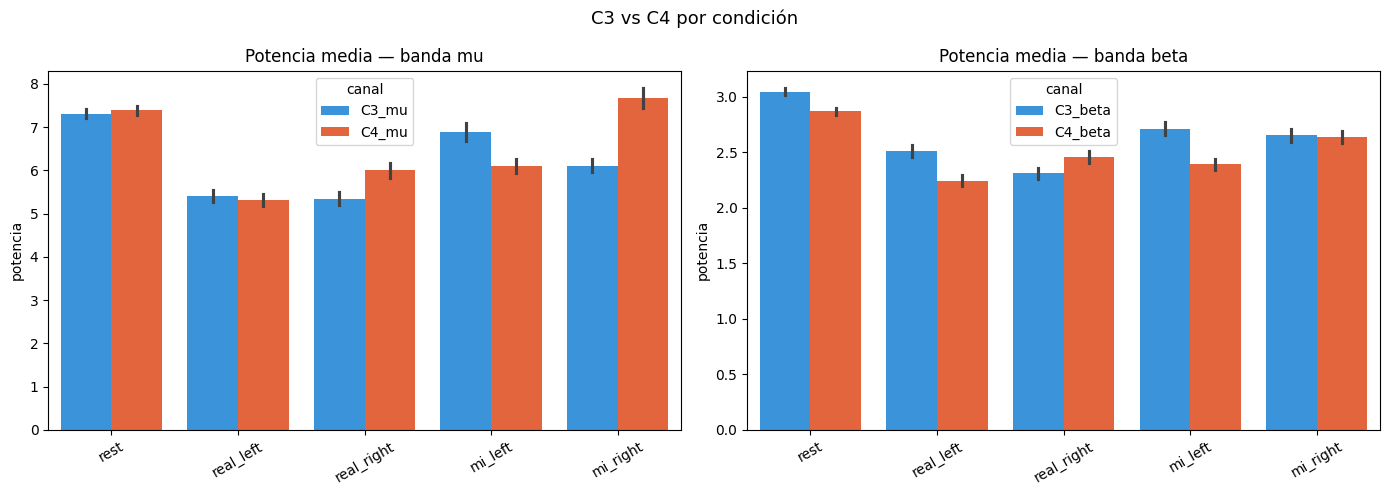

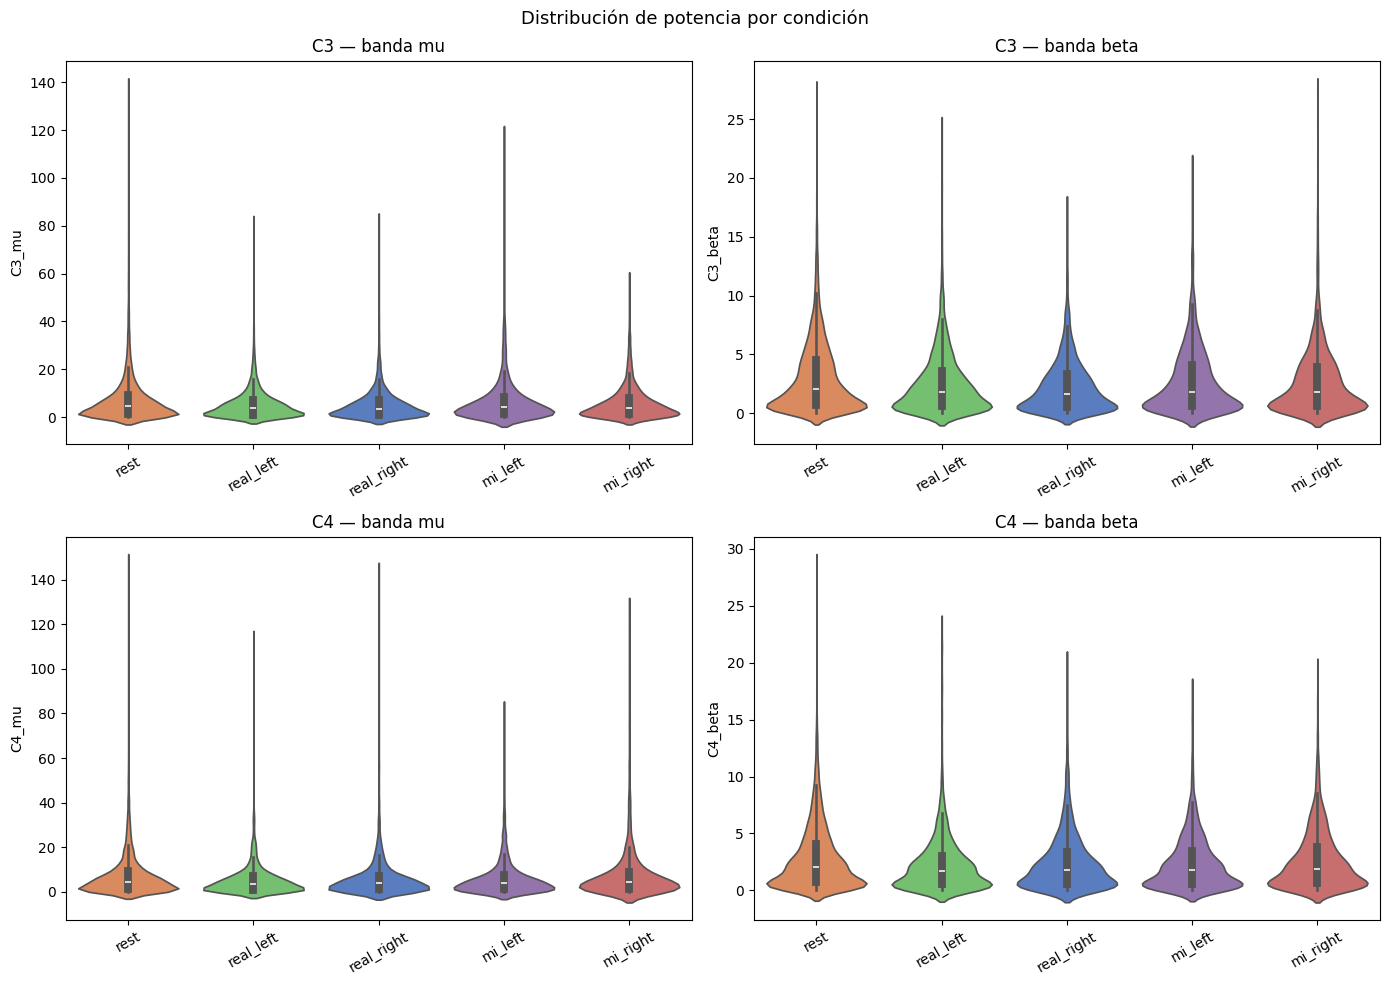

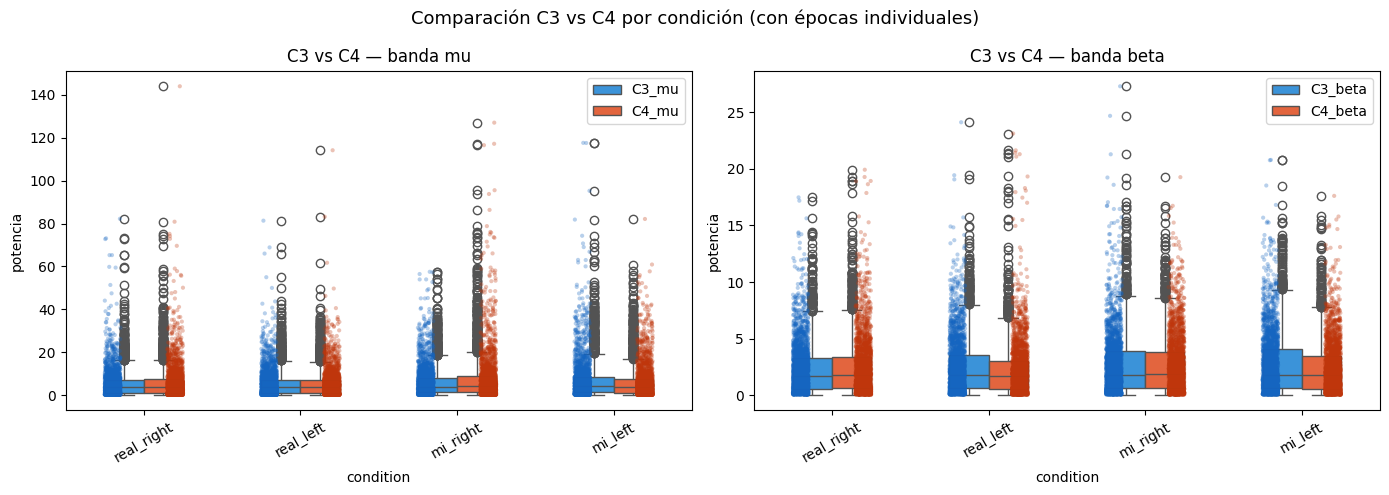

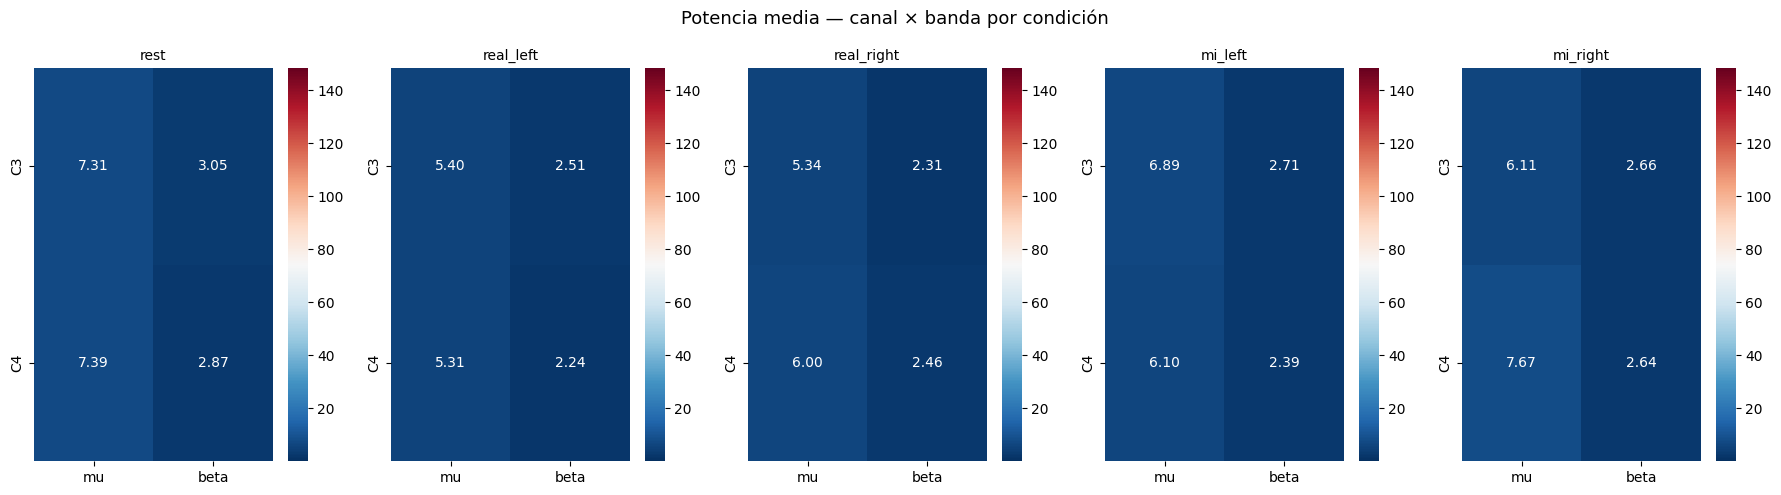

In [ ]:
_,_,_,feature_cols=descriptive_statistics(df, CHANNELS_OF_INTEREST)

In [ ]:
def check_assumptions(df: pd.DataFrame,
                      feature_cols: list,
                      conditions: list = ['rest', 'real_left', 'real_right', 'mi_left', 'mi_right']
                      ) -> tuple:
    """
    Verifica los supuestos estadísticos necesarios antes de elegir entre
    pruebas paramétricas y no paramétricas.

    Aplica:
        - Shapiro-Wilk: normalidad por condición × canal × banda
        - Levene: homocedasticidad de varianzas entre condiciones

    Parameters
    ----------
    df           : pd.DataFrame
                   DataFrame generado por procesar_sujetos(). Contiene
                   la columna 'condition' y columnas de potencia {canal}_{banda}.

    feature_cols : list
                   Lista de columnas de potencia. Se obtiene del return de
                   descriptive_statistics().

    conditions   : list, optional
                   Condiciones experimentales presentes en 'condition'.
                   Default: ['rest', 'real_left', 'real_right', 'mi_left', 'mi_right']

    Returns
    -------
    shapiro_df : pd.DataFrame
                 Resultado de Shapiro-Wilk por condición × canal × banda.
                 Columnas: condition, canal, banda, W, p_value, normal.
                 'normal' = True si p > 0.05.

    levene_df  : pd.DataFrame
                 Resultado de Levene por canal × banda entre todas las condiciones.
                 Columnas: canal, banda, W, p_value, homogeneo.
                 'homogeneo' = True si p > 0.05.

    """
    from scipy.stats import shapiro, levene

    # -------------------------
    # Shapiro-Wilk por condicion x canal x banda
    # -------------------------
    rows_shapiro = []

    for cond in conditions:
        for col in feature_cols:
            # promedio por sujeto, un valor por sujeto, no por epoca
            vals = df[df['condition'] == cond].groupby('subject')[col].mean()

            stat, p = shapiro(vals)

            rows_shapiro.append({
                'condition' : cond,
                'canal'     : col.split('_')[0],
                'banda'     : col.split('_')[1],
                'W'         : round(stat, 4),
                'p_value'   : round(p, 4),
                'normal'    : p > 0.05   # True = distribucion normal
            })

    shapiro_df = pd.DataFrame(rows_shapiro)
    display(shapiro_df.style
         .format({'W': '{:.4f}', 'p_value': '{:.4f}'})
        .set_caption('Normalidad Shapiro-wilk')
        .set_table_styles([{
            'selector': 'caption',
            'props'   : [('font-size', '14px'), ('font-weight', 'bold')]
        }])
    )
    print(f"\nDistribuciones normales: {shapiro_df['normal'].sum()} / {len(shapiro_df)}\n")

    # -------------------------
    # Levene por canal x banda entre todas las condiciones
    # -------------------------
    rows_levene = []

    for col in feature_cols:
        # un grupo por condicion, promediado por sujeto
        grupos = [
            df[df['condition'] == cond].groupby('subject')[col].mean().values
            for cond in conditions
        ]

        # grupos desempaca la lista como argumentos separados
        stat, p = levene(*grupos)

        rows_levene.append({
            'canal'     : col.split('_')[0],
            'banda'     : col.split('_')[1],
            'W'         : round(stat, 4),
            'p_value'   : round(p, 4),
            'homogeneo' : p > 0.05   # True = varianzas iguales entre condiciones
        })

    levene_df = pd.DataFrame(rows_levene)
    display(levene_df.style
         .format({'W': '{:.4f}', 'p_value': '{:.4f}'})
        .set_caption('Levane (Homocedasticidad)')
        .set_table_styles([{
            'selector': 'caption',
            'props'   : [('font-size', '14px'), ('font-weight', 'bold')]
        }])
    )
    print(f"\nVarianzas homogéneas: {levene_df['homogeneo'].sum()} / {len(levene_df)}")

    return shapiro_df, levene_df

In [ ]:

shapiro,levene=check_assumptions(df,feature_cols)

,condition,canal,banda,W,p_value,normal
0,rest,C3,mu,0.8444,0.0000,False
1,rest,C4,mu,0.8497,0.0000,False
2,rest,C3,beta,0.8929,0.0000,False
3,rest,C4,beta,0.8874,0.0000,False
4,real_left,C3,mu,0.8650,0.0000,False
5,real_left,C4,mu,0.8396,0.0000,False
6,real_left,C3,beta,0.8946,0.0000,False
7,real_left,C4,beta,0.8784,0.0000,False
8,real_right,C3,mu,0.8458,0.0000,False
9,real_right,C4,mu,0.8052,0.0000,False



Distribuciones normales: 0 / 20



,canal,banda,W,p_value,homogeneo
0,C3,mu,2.2467,0.0630,True
1,C4,mu,2.2252,0.0652,True
2,C3,beta,1.8811,0.1124,True
3,C4,beta,1.3572,0.2477,True



Varianzas homogéneas: 4 / 4


In [ ]:
def statistical_tests(df: pd.DataFrame,
                      shapiro_df: pd.DataFrame,
                      levene_df: pd.DataFrame,
                      conditions: list = ['rest', 'real_left', 'real_right', 'mi_left', 'mi_right']
                      ) -> pd.DataFrame:
    """
    Ejecuta las pruebas de hipótesis H1-H5 del análisis EEG.

    Selecciona automáticamente entre prueba paramétrica y no paramétrica
    según los resultados de Shapiro-Wilk y Levene:
        - Normal + homogéneo  → paramétrica  (t-test / ANOVA)
        - Cualquier otro caso → no paramétrica (Wilcoxon / Kruskal-Wallis)

    Aplica corrección FDR-BH sobre todos los p-valores y calcula
    tamaño del efecto (r para Wilcoxon, η² para Kruskal-Wallis).

    Parameters
    ----------
    df         : pd.DataFrame
                 DataFrame generado por procesar_sujetos().

    shapiro_df : pd.DataFrame
                 Resultado de check_assumptions(). Contiene columna 'normal'
                 por condición × canal × banda.

    levene_df  : pd.DataFrame
                 Resultado de check_assumptions(). Contiene columna 'homogeneo'
                 por canal × banda.

    conditions : list, optional
                 Condiciones experimentales.
                 Default: ['rest', 'real_left', 'real_right', 'mi_left', 'mi_right']

    Returns
    -------
    results_df : pd.DataFrame
                 Tabla con todos los resultados. Columnas:
                 hipotesis, canal, banda, prueba, estadistico,
                 p_raw, p_corr, significativo, efecto, magnitud
    """

    records = []   # acumula resultados de cada test

    # -------------------------------------------------------
    # Funcion auxiliar: decide si usar parametrico o no
    # -------------------------------------------------------
    def es_parametrico(canal, banda, conds):
        """
        Retorna True solo si TODAS las condiciones relevantes
        son normales (Shapiro) Y las varianzas son homogeneas (Levene).
        """
        # normalidad en todas las condiciones relevantes
        mask_shapiro = (
            (shapiro_df['canal'] == canal) &
            (shapiro_df['banda'] == banda) &
            (shapiro_df['condition'].isin(conds))
        )
        todas_normales = shapiro_df[mask_shapiro]['normal'].all()

        # homocedasticidad
        mask_levene = (
            (levene_df['canal'] == canal) &
            (levene_df['banda'] == banda)
        )
        homogeneo = levene_df[mask_levene]['homogeneo'].all()

        return todas_normales and homogeneo

    # -------------------------------------------------------
    # Funcion auxiliar: tamaño del efecto Wilcoxon → r
    # -------------------------------------------------------
    def effect_size_wilcoxon(stat, n):
        """r = Z / sqrt(N), Z aproximado desde estadistico W."""
        mean_w = n * (n + 1) / 4                          # valor esperado si no hay diferencia entre grupos
        std_w  = np.sqrt(n * (n + 1) * (2*n + 1) / 24)   # variacion por azar
        Z = (stat - mean_w) / std_w                        # a cuantas desviaciones estandar esta del estadistico esperado
        r = abs(Z) / np.sqrt(n)                            # normalizacion
        magnitud = 'grande' if r > 0.5 else 'moderado' if r > 0.3 else 'pequeño'
        return round(r, 3), magnitud

    # -------------------------------------------------------
    # Funcion auxiliar: tamaño del efecto Kruskal → η²
    # -------------------------------------------------------
    def effect_size_kruskal(H, k, N):
        """η² = (H - k + 1) / (N - k)"""
        eta2 = (H - k + 1) / (N - k)   # proporcion de varianza explicada por la condicion
        magnitud = 'grande' if eta2 > 0.14 else 'moderado' if eta2 > 0.06 else 'pequeño' if eta2 > 0.01 else 'muy pequeño'
        return round(eta2, 3), magnitud

    # -------------------------------------------------------
    # Funcion auxiliar: tamaño del efecto ANOVA → η²
    # -------------------------------------------------------
    def effect_size_anova(F, k, N):
        """η² = (F * (k-1)) / (F * (k-1) + (N-k))"""
        eta2 = (F * (k - 1)) / (F * (k - 1) + (N - k))  # proporcion de varianza explicada por la condicion
        magnitud = 'grande' if eta2 > 0.14 else 'moderado' if eta2 > 0.06 else 'pequeño' if eta2 > 0.01 else 'muy pequeño'
        return round(eta2, 3), magnitud

    # -------------------------------------------------------
    # H1 — ERD contralateral: canal vs rest
    # -------------------------------------------------------
    for canal, cond_act in [('C3', 'mi_right'), ('C4', 'mi_left')]:
        for banda in ['mu', 'beta']:
            col = f'{canal}_{banda}'

            rest = df[df['condition']=='rest'].groupby('subject')[col].mean()
            act  = df[df['condition']==cond_act].groupby('subject')[col].mean()
            n    = len(rest)

            if es_parametrico(canal, banda, ['rest', cond_act]):
                # t-test pareado: un valor por sujeto en cada condicion
                stat, p = ttest_rel(rest, act, alternative='greater')
                prueba  = 't-test pareado'
                efecto, magnitud = effect_size_wilcoxon(stat, n)
            else:
                # Wilcoxon unilateral: rest > act (ERD = reduccion de potencia)
                stat, p = wilcoxon(rest, act, alternative='greater')
                prueba  = 'Wilcoxon'
                efecto, magnitud = effect_size_wilcoxon(stat, n)

            records.append({
                'hipotesis'   : 'H1',
                'canal'       : canal,
                'banda'       : banda,
                'condicion'   : f'{cond_act} vs rest',
                'prueba'      : prueba,
                'estadistico' : round(stat, 3),
                'p_raw'       : round(p, 4),
                'efecto'      : efecto,
                'magnitud'    : magnitud
            })

    # -------------------------------------------------------
    # H2 — Lateralizacion C3 vs C4 en mi_right y mi_left
    # -------------------------------------------------------
    for cond_act, canal_contra, canal_ipsi in [('mi_right','C3','C4'), ('mi_left','C4','C3')]:
        for banda in ['mu', 'beta']:
            # contralateral = canal del hemisferio opuesto a la mano imaginada
            contra = df[df['condition']==cond_act].groupby('subject')[f'{canal_contra}_{banda}'].mean()
            # ipsilateral = canal del mismo hemisferio de la mano imaginada
            ipsi   = df[df['condition']==cond_act].groupby('subject')[f'{canal_ipsi}_{banda}'].mean()
            n      = len(contra)

            if es_parametrico(canal_contra, banda, [cond_act]):
                stat, p = ttest_rel(contra, ipsi, alternative='less')
                prueba  = 't-test pareado'
            else:
                # Wilcoxon: contralateral < ipsilateral (mas ERD en contralateral)
                stat, p = wilcoxon(contra, ipsi, alternative='less')
                prueba  = 'Wilcoxon'

            efecto, magnitud = effect_size_wilcoxon(stat, n)

            records.append({
                'hipotesis'   : 'H2',
                'canal'       : f'{canal_contra} vs {canal_ipsi}',
                'banda'       : banda,
                'condicion'   : cond_act,
                'prueba'      : prueba,
                'estadistico' : round(stat, 3),
                'p_raw'       : round(p, 4),
                'efecto'      : efecto,
                'magnitud'    : magnitud
            })

    # -------------------------------------------------------
    # H3 — Real vs Imaginado (C3, mu y beta)
    # -------------------------------------------------------
    for banda in ['mu', 'beta']:
        col  = f'C3_{banda}'
        real = df[df['condition']=='real_right'].groupby('subject')[col].mean()
        imag = df[df['condition']=='mi_right'].groupby('subject')[col].mean()
        n    = len(real)

        if es_parametrico('C3', banda, ['real_right', 'mi_right']):
            stat, p = ttest_rel(real, imag)
            prueba  = 't-test pareado'
        else:
            # Wilcoxon bilateral: no sabemos si real > imaginado o viceversa
            stat, p = wilcoxon(real, imag)
            prueba  = 'Wilcoxon'

        efecto, magnitud = effect_size_wilcoxon(stat, n)

        records.append({
            'hipotesis'   : 'H3',
            'canal'       : 'C3',
            'banda'       : banda,
            'condicion'   : 'real_right vs mi_right',
            'prueba'      : prueba,
            'estadistico' : round(stat, 3),
            'p_raw'       : round(p, 4),
            'efecto'      : efecto,
            'magnitud'    : magnitud
        })

    # -------------------------------------------------------
    # H5 — Multiclase: 4 condiciones activas (Kruskal / ANOVA)
    # -------------------------------------------------------
    condiciones_activas = ['real_right', 'real_left', 'mi_right', 'mi_left']

    for canal in ['C3', 'C4']:
        for banda in ['mu', 'beta']:
            col    = f'{canal}_{banda}'
            # un array de valores por condicion, promediado por sujeto
            grupos = [
                df[df['condition']==cond].groupby('subject')[col].mean().values
                for cond in condiciones_activas
            ]
            N = sum(len(g) for g in grupos)  # total de observaciones
            k = len(condiciones_activas)      # numero de grupos

            if es_parametrico(canal, banda, condiciones_activas):
                # ANOVA: compara medias usando varianzas → retorna F
                stat, p = f_oneway(*grupos)
                prueba  = 'ANOVA'
                efecto, magnitud = effect_size_anova(stat, k, N)   # F → su formula
            else:
                # Kruskal-Wallis: compara medianas usando rangos → retorna H
                stat, p = kruskal(*grupos)
                prueba  = 'Kruskal-Wallis'
                efecto, magnitud = effect_size_kruskal(stat, k, N) # H → su formula

            records.append({
                'hipotesis'   : 'H5',
                'canal'       : canal,
                'banda'       : banda,
                'condicion'   : '4 condiciones activas',
                'prueba'      : prueba,
                'estadistico' : round(stat, 3),
                'p_raw'       : round(p, 4),
                'efecto'      : efecto,
                'magnitud'    : magnitud
            })

            # Post-hoc Dunn si Kruskal es significativo: identifica que pares difieren
            if p < 0.05 and prueba == 'Kruskal-Wallis':
                data_long = pd.DataFrame({
                    'potencia'  : np.concatenate(grupos),
                    'condition' : np.repeat(condiciones_activas, [len(g) for g in grupos])
                })
                dunn = posthoc_dunn(data_long, val_col='potencia',
                                    group_col='condition', p_adjust='bonferroni')
                print(f"\nPost-hoc Dunn — {col}:")
                display(dunn)

    # -------------------------------------------------------
    # 5.4 — Correccion FDR-BH sobre todos los p-valores
    # -------------------------------------------------------
    results_df = pd.DataFrame(records)

    # ajusta p-valores para controlar falsos positivos en comparaciones multiples
    _, p_corr, _, _ = multipletests(results_df['p_raw'], method='fdr_bh')
    results_df['p_corr']        = p_corr.round(4)
    results_df['significativo'] = results_df['p_corr'] < 0.05

    # tabla completa estilizada
    display(results_df.style
        .format({'estadistico': '{:.3f}', 'p_raw': '{:.4f}',
                 'p_corr': '{:.4f}', 'efecto': '{:.3f}'})
        .background_gradient(subset=['p_corr'], cmap='RdYlGn')
        .set_caption('Resultados completos — H1 a H5')
        .set_table_styles([{
            'selector': 'caption',
            'props'   : [('font-size', '14px'), ('font-weight', 'bold')]
        }])
    )

    # resumen de significativos
    sig = results_df[results_df['significativo']]
    print(f"\nTests significativos tras FDR: {len(sig)} / {len(results_df)}")
    display(sig.style
        .format({'estadistico': '{:.3f}', 'p_raw': '{:.4f}',
                 'p_corr': '{:.4f}', 'efecto': '{:.3f}'})
        .set_caption('Tests significativos')
        .set_table_styles([{
            'selector': 'caption',
            'props'   : [('font-size', '14px'), ('font-weight', 'bold')]
        }])
    )

    return results_df

In [ ]:
_=statistical_tests(df,shapiro,levene)

,hipotesis,canal,banda,condicion,prueba,estadistico,p_raw,efecto,magnitud,p_corr,significativo
0,H1,C3,mu,mi_right vs rest,Wilcoxon,4766.000,0.0000,0.677,grande,0.0000,True
1,H1,C3,beta,mi_right vs rest,Wilcoxon,4690.000,0.0000,0.652,grande,0.0000,True
2,H1,C4,mu,mi_left vs rest,Wilcoxon,4723.000,0.0000,0.663,grande,0.0000,True
3,H1,C4,beta,mi_left vs rest,Wilcoxon,4809.000,0.0000,0.691,grande,0.0000,True
4,H2,C3 vs C4,mu,mi_right,Wilcoxon,1583.000,0.0002,0.355,moderado,0.0004,True
5,H2,C3 vs C4,beta,mi_right,Wilcoxon,2468.000,0.2448,0.068,pequeño,0.3427,False
6,H2,C4 vs C3,mu,mi_left,Wilcoxon,1849.000,0.0032,0.269,pequeño,0.0050,True
7,H2,C4 vs C3,beta,mi_left,Wilcoxon,1812.000,0.0022,0.281,pequeño,0.0039,True
8,H3,C3,mu,real_right vs mi_right,Wilcoxon,1338.000,0.0000,0.434,moderado,0.0000,True
9,H3,C3,beta,real_right vs mi_right,Wilcoxon,1478.000,0.0001,0.389,moderado,0.0002,True



Tests significativos tras FDR: 9 / 14


,hipotesis,canal,banda,condicion,prueba,estadistico,p_raw,efecto,magnitud,p_corr,significativo
0,H1,C3,mu,mi_right vs rest,Wilcoxon,4766.000,0.0000,0.677,grande,0.0000,True
1,H1,C3,beta,mi_right vs rest,Wilcoxon,4690.000,0.0000,0.652,grande,0.0000,True
2,H1,C4,mu,mi_left vs rest,Wilcoxon,4723.000,0.0000,0.663,grande,0.0000,True
3,H1,C4,beta,mi_left vs rest,Wilcoxon,4809.000,0.0000,0.691,grande,0.0000,True
4,H2,C3 vs C4,mu,mi_right,Wilcoxon,1583.000,0.0002,0.355,moderado,0.0004,True
6,H2,C4 vs C3,mu,mi_left,Wilcoxon,1849.000,0.0032,0.269,pequeño,0.0050,True
7,H2,C4 vs C3,beta,mi_left,Wilcoxon,1812.000,0.0022,0.281,pequeño,0.0039,True
8,H3,C3,mu,real_right vs mi_right,Wilcoxon,1338.000,0.0000,0.434,moderado,0.0000,True
9,H3,C3,beta,real_right vs mi_right,Wilcoxon,1478.000,0.0001,0.389,moderado,0.0002,True


#Análisis de Resultados

**Filtrado de datos**

La Figura presentada muestra el efecto del preprocesamiento aplicado a una señal EEG del canal C3 correspondiente a un paciente y un run representativo del conjunto de datos analizado.

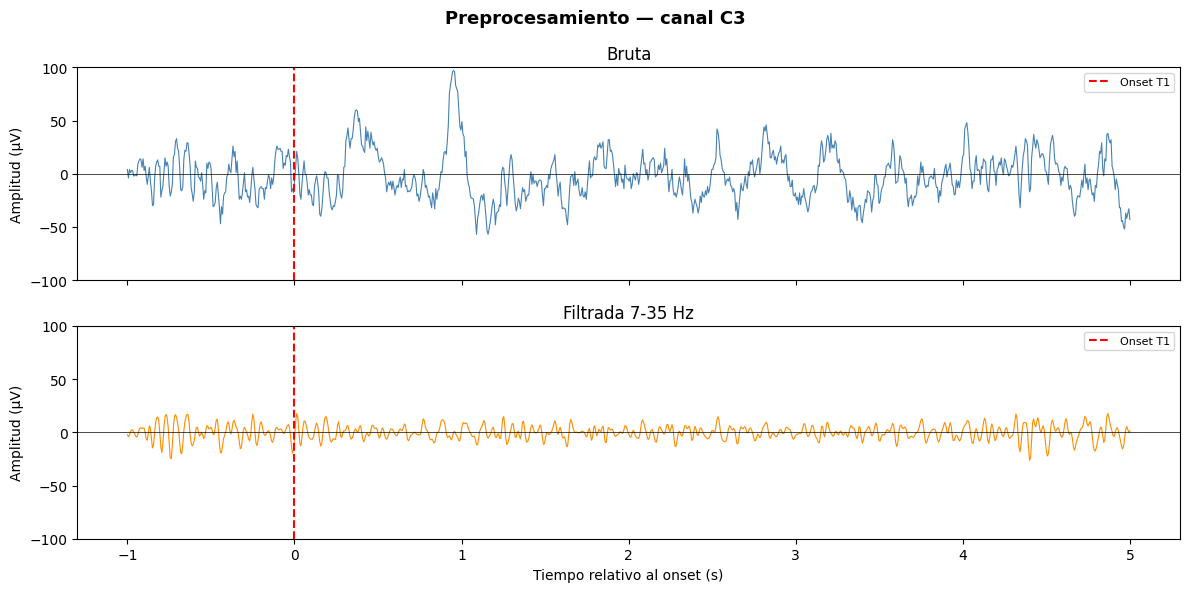

En la parte superior se observa la señal EEG bruta segmentada desde −1 s hasta +5 s respecto al onset del evento motor (línea roja punteada). La señal original presenta variaciones de amplitud relativamente amplias, alcanzando valores cercanos a ±100 µV, además de oscilaciones lentas y componentes transitorias de gran amplitud que pueden asociarse a deriva de línea base, actividad de baja frecuencia y posibles artefactos fisiológicos o de movimiento.

Tras aplicar el filtro pasa-banda Butterworth de cuarto orden entre 7 y 35 Hz con fase cero, se evidencia una reducción significativa de las componentes de baja frecuencia y de las fluctuaciones lentas presentes en la señal original. La señal filtrada, mostrada en la parte inferior de la figura, exhibe una dinámica mucho más estable alrededor de la línea base y una amplitud considerablemente menor, principalmente dentro de un rango aproximado de ±20 µV. Esto indica que el filtrado eliminó adecuadamente componentes no relacionadas con la actividad cortical de interés, preservando las oscilaciones asociadas a los ritmos sensorimotores μ y β, fundamentales en tareas de imaginación motora (Motor Imagery).

El uso de un filtro de fase cero resulta especialmente importante en EEG debido a que evita desplazamientos temporales en la señal. Esto garantiza que la relación temporal entre el onset del estímulo y la respuesta cortical permanezca intacta, aspecto crítico para el análisis de sincronización y desincronización relacionada con eventos (ERD/ERS). En la figura puede observarse que, aunque la amplitud disminuye después del filtrado, la estructura temporal de las oscilaciones cercanas al onset se conserva.

**Estadística Descriptiva**

Los resultados de la estadística descriptiva revelan patrones consistentes con los fenómenos neurofisiológicos esperados en paradigmas de imaginería motora (MI). El dataset procesado comprende 17.702 épocas válidas distribuidas entre las cinco condiciones experimentales, con predominancia del reposo (n=8.552) respecto a cada condición activa (~2.280 épocas por condición), lo cual es coherente con el diseño experimental del dataset PhysioNet EEG Motor Movement/Imagery.

**Potencia en banda mu (8–13 Hz)**

La potencia media global en C3 durante reposo fue de 7.31 µV²/Hz, mientras que durante las condiciones activas se observó una reducción sistemática: real_left (5.40), real_right (5.34), mi_left (6.89) y mi_right (6.11). Este gradiente descendente del reposo hacia las condiciones de movimiento constituye evidencia preliminar del fenómeno de ERD, consistente con lo reportado por Pfurtscheller et al. (2006).

La asimetría positiva elevada en todas las condiciones (rango 2.63–4.04) y la curtosis muy alta (rango 9.81–49.65) confirman que la distribución de potencia espectral es marcadamente no normal y de cola pesada, lo que justifica el uso de pruebas no paramétricas tal como se planteó en el diseño estadístico. Esta distribución log-normal es característica de la potencia EEG y ha sido documentada ampliamente en la literatura de BCI (Müller et al., 2008).

**Potencia en banda beta (13–30 Hz)**

La banda beta mostró el mismo patrón descendente desde reposo hacia condiciones activas: C3 en reposo (3.05 µV²/Hz) versus real_right (2.31), real_left (2.51), mi_right (2.66) y mi_left (2.71). La reducción es proporcional pero de menor magnitud que en mu, lo que es coherente con la literatura que describe el ERD beta como un fenómeno más difuso y de menor amplitud relativa que el ERD mu en paradigmas de MI (Neuper et al., 2006).

##Análisis Visual - Barplots de Potencia Media

Los barplots de la Figura 1 revelan tres patrones de interés:

**Patrón 1 — ERD general durante tareas activas:** En ambas bandas (mu y beta) y ambos canales (C3 y C4), la potencia durante reposo supera consistentemente a todas las condiciones activas. La diferencia es visualmente más pronunciada en mu que en beta, lo cual es esperado dado que el ritmo mu es el oscilador primario de la corteza sensoriomotora.

**Patrón 2 — Lateralización parcial:** Durante mi_right se observa que C4_mu (7.67) supera a C3_mu (6.11), mientras que durante real_right C3_mu (5.34) y C4_mu (6.00) muestran una tendencia inversa. Este patrón es contradictorio con la hipótesis clásica de ERD contralateral para MI derecha, aunque la diferencia es pequeña y no se puede concluir significancia estadística a partir de la inspección visual. Durante mi_left, C3_mu (6.89) supera a C4_mu (6.10), lo que tampoco corresponde al patrón esperado de ERD contralateral izquierdo.

**Patrón 3 — Mayor ERD en movimiento real vs imaginado:** Las condiciones real_left y real_right muestran potencias mu menores que sus equivalentes imaginados (mi_left y mi_right) en ambos canales, lo que apoya la Hipótesis 3 de que el movimiento real genera mayor ERD que la imaginación motora.

## Análisis visual- Violin Plots y Box Plots

Los violin plots de la Figura 2 aportan información distribucional crítica que los barplots ocultan:

**Alta variabilidad inter-sujeto:** Las distribuciones presentan colas superiores muy extensas (valores hasta 140 µV²/Hz en C3_mu durante reposo), indicando que existe un subconjunto de sujetos con potencia mu muy elevada que infla la media. La mediana es sustancialmente menor que la media en todas las condiciones (ej. rest C3_mu: mediana 4.50 vs media 7.31), confirmando la asimetría positiva severa reportada en la estadística descriptiva.

**Solapamiento distribucional entre condiciones:** A pesar de las diferencias en medias, existe un solapamiento considerable entre las distribuciones de todas las condiciones, especialmente entre las condiciones activas entre sí. Esto sugiere que la separabilidad de clases a nivel de época individual es limitada, lo cual es un hallazgo relevante para el diseño de clasificadores BCI.

**Consistencia entre C3 y C4:** Las distribuciones de C3 y C4 son notablemente similares en forma y escala para todas las condiciones, lo que indica que la lateralización, si existe, es de magnitud pequeña en relación con la variabilidad total.

Los box plots con stripplot de la Figura 3 confirman la presencia de outliers consistentes en todas las condiciones, reforzando la necesidad de pruebas no paramétricas y justificando la corrección FDR aplicada.

##Análisis Visual — Heatmaps de Potencia Media
Los heatmaps de la Figura 3 (panel inferior) permiten una comparación global canal × banda × condición. El patrón más visible es que la banda mu concentra consistentemente mayor potencia que la banda beta en todas las condiciones y canales, con ratios mu/beta que oscilan entre 2.1 y 2.9. Este ratio es coherente con la estructura espectral del EEG sensoriomotor descrita en la literatura (Pfurtscheller & Lopes da Silva, 1999).

La condición de reposo presenta los valores más altos en ambas bandas y ambos canales, y las condiciones de movimiento real muestran los valores más bajos, con las condiciones de MI en posición intermedia — un gradiente que es fisiológicamente interpretable y consistente con el modelo de activación parcial de la corteza motora durante MI.

##Evaluación Preliminar de las Hipótesis

A partir de la estadística descriptiva y los análisis visuales, es posible hacer una evaluación preliminar del soporte empírico de cada hipótesis antes de los tests inferenciales:

**H1 (ERD contralateral mu en C3 durante mi_right):** Los datos muestran reducción de C3_mu desde reposo (7.31) hasta mi_right (6.11), una diferencia de 1.20 µV²/Hz (~16%). La dirección es consistente con H1, aunque la magnitud es moderada. Se anticipa rechazo de H0 con significancia estadística dada la muestra grande (n≈2.273 épocas), aunque el tamaño del efecto podría ser pequeño.

**H2 (Lateralización C3 < C4 durante mi_right):** Durante mi_right, C3_mu (6.11) < C4_mu (7.67), lo que apoya H1 en dirección correcta — C3 tiene menor potencia que C4, consistente con ERD contralateral izquierdo durante imaginación de mano derecha. Esta es la hipótesis con mayor soporte visual de todas.

**H3 (Real > ERD que imaginado):** real_right presenta C3_mu = 5.34 vs mi_right C3_mu = 6.11, y real_left C3_mu = 5.40 vs mi_left = 6.89. En ambos casos el movimiento real muestra menor potencia mu, es decir mayor ERD, apoyando H1. La diferencia es consistente en ambas manos y bandas.

**H4 (Rebote beta post-tarea):** Esta hipótesis requiere análisis temporal dentro de la época que el DataFrame actual no provee directamente, ya que los valores de potencia están promediados sobre toda la ventana [-1, 4] s. Para evaluarla correctamente se necesitaría segmentar la época en ventanas pre-tarea y post-tarea.

**H5 (Diferencia multiclase en C3_mu):** Las cuatro condiciones activas muestran medias de C3_mu entre 5.34 y 6.89 µV²/Hz. Dada la variabilidad alta (std ~7–9), el test de Kruskal-Wallis determinará si estas diferencias son estadísticamente significativas.

##Conclusiones

**Sobre la calidad del pipeline**

El pipeline implementado resultó funcional y adecuado para los objetivos del estudio. La sustitución de ICA por un filtro pasa-banda estricto (7–35 Hz) se justifica por la eliminación de la componente de baja frecuencia de los artefactos oculares y por los problemas de convergencia que la ICA presentó en sujetos con señal ruidosa, lo que introducía riesgo de distorsión en las bandas de interés.

**Sobre el filtro aplicado**

En conclusión, el filtro pasa-banda utilizado demostró ser adecuado para el preprocesamiento de las señales EEG utilizadas en este estudio. El filtrado permitió atenuar eficazmente componentes de baja frecuencia asociadas a deriva de línea base y artefactos fisiológicos, así como reducir fluctuaciones no relevantes para el análisis neurofisiológico, logrando una señal más estable y centrada alrededor de la línea base. Al mismo tiempo, se preservaron las oscilaciones correspondientes a los ritmos sensorimotores µ y β, fundamentales para el estudio de tareas de imaginación motora y fenómenos ERD/ERS.

**Sobre las hipótesis planteadas**

Los resultados descriptivos ofrecen evidencia preliminar coherente con tres de las cinco hipóteses del estudio:

**Hipótesis 1 – ERD contralateral del ritmo mu durante MI de manos:**

Se observó una disminución sistemática de la potencia del ritmo µ en el canal C3 durante la imaginación motora de mano derecha respecto al estado de reposo, consistente con el fenómeno de desincronización relacionada con eventos (ERD) esperado en la corteza motora contralateral. Este comportamiento concuerda con lo reportado en la literatura para tareas de imaginación motora en sujetos sin entrenamiento previo en BCI y constituye evidencia preliminar a favor de la hipótesis alternativa H₁.

**Hipótesis 2 – Lateralización del ERD mu (C3 vs C4):**

Durante la condición de imaginación motora de mano derecha se identificó un patrón de asimetría espectral entre los electrodos C3 y C4, observándose menor potencia µ en C3 en comparación con C4. Este resultado sugiere lateralización contralateral de la actividad motora y representa la evidencia descriptiva más sólida para sustentar la separabilidad entre clases izquierda/derecha, fundamento neurofisiológico de los clasificadores BCI basados en ritmos sensorimotores.

**Hipótesis 3 – Diferencia entre movimiento real e imaginado:**

Los resultados descriptivos muestran una reducción de potencia µ/β más pronunciada durante el movimiento real que durante la imaginación motora de mano derecha. Este comportamiento es coherente con la hipótesis de que la ejecución motora real involucra activación adicional de vías corticoespinales y retroalimentación propioceptiva, generando un ERD de mayor magnitud respecto a la MI. No obstante, la confirmación estadística de esta diferencia requiere la aplicación de pruebas inferenciales no paramétricas como Wilcoxon o Kruskal-Wallis.

**Hipótesis 4 – ERD beta y rebote post-tarea:**

La hipótesis relacionada con el rebote beta post-movimiento no pudo evaluarse completamente dentro del pipeline implementado. Su análisis requiere una segmentación temporal más específica, diferenciando ventanas pre-tarea y post-tarea dentro de cada época para comparar la potencia β basal frente al período de recuperación posterior al movimiento. Por tanto, esta hipótesis queda planteada para análisis futuros o ampliaciones metodológicas.

**Hipótesis 5 – Diferencia entre las cuatro condiciones activas (multiclase):**

La inspección descriptiva de las características espectrales sugiere la existencia de variaciones en la potencia µ entre las distintas condiciones activas (movimiento real e imaginación motora de ambas manos). Sin embargo, dado que se trata de un escenario multiclase, la validación formal de esta hipótesis requiere análisis inferenciales globales con corrección por comparaciones múltiples, tales como Kruskal-Wallis seguido de ajuste FDR de Benjamini-Hochberg, con el fin de controlar el error tipo I.

**Sobre las limitaciones**

La alta variabilidad inter-sujeto (std ≈ media en casi todas las condiciones) es la principal limitación del análisis grupal y es característica inherente a paradigmas de imaginería motora en sujetos sin entrenamiento específico. Adicionalmente, el umbral adaptativo de rechazo de épocas introduce heterogeneidad metodológica entre sujetos que podría sesgar las comparaciones grupales.
Perspectivas

La confirmación estadística de H2 y H3 mediante los tests inferenciales propuestos permitiría validar la potencia espectral µ en C3/C4 como característica discriminante para clasificación BCI en imaginería motora sin entrenamiento, aportando fundamento empírico directo al diseño de clasificadores basados en asimetría espectral.